In [5]:
import cv2
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

MM_TO_PT = 72 / 25.4
font_size_mm = 2.5
font_size_pt = font_size_mm * MM_TO_PT  # ≈ 8.5 pt
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": font_size_pt,
    "axes.labelsize": font_size_pt,
    "axes.titlesize": font_size_pt,
    "xtick.labelsize": font_size_pt,
    "ytick.labelsize": font_size_pt,
    "legend.fontsize": font_size_pt,
})

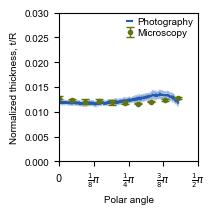

In [8]:

colors=["#215CAF","#627313"] #blue, green
p_phi    = np.loadtxt('thickness-plotting-00-p-phi.csv', delimiter=',')
p_t_mean = np.loadtxt('thickness-plotting-00-p-t_mean.csv', delimiter=',')
p_t_std  = np.loadtxt('thickness-plotting-00-p-t_std.csv', delimiter=',')
t_phi    = np.loadtxt('thickness-plotting-00-t-phi.csv', delimiter=',')
t_t_mean = np.loadtxt('thickness-plotting-00-t-t_mean.csv', delimiter=',')
t_t_std  = np.loadtxt('thickness-plotting-00-t-t_std.csv', delimiter=',')

    
fig, ax = plt.subplots(figsize=(50/25.4, 50/25.4))

ax.plot(p_phi, p_t_mean, color=colors[0], label="Photography")

ax.fill_between(
    p_phi,
    p_t_mean - p_t_std,
    p_t_mean + p_t_std,
    color=colors[0],
    alpha=0.3,
)
ax.errorbar(
    t_phi,
    t_t_mean,
    yerr=t_t_std,
    fmt='o',
    markersize=3,
    elinewidth=1,
    capsize=3,
    color=colors[1],
    label="Microscopy")

plt.xlabel("Polar angle")
plt.ylabel("Normalized thickness, t/R")

ticks = [0, np.pi/8, np.pi/4, 3*np.pi/8, np.pi/2]
tick_labels = [ r"$0$",  r"$\frac{1}{8} \pi$",
               r"$\frac{1}{4} \pi$", r"$\frac{3}{8} \pi$",  r"$\frac{1}{2} \pi$"]

plt.xticks(ticks, tick_labels)
plt.xlim([0, np.pi/2])
plt.ylim([0,0.03])

ax.legend(
    frameon=False,
    borderpad=0.0,
    labelspacing=0.2,
    handletextpad=0.5,
    handlelength=0.5)

plt.tight_layout(pad=0.1)

plt.show()